In [1]:
!pip install -q tensorflow keras-tuner transformers datasets accelerate scikit-learn nltk seaborn matplotlib pandas numpy

In [2]:
import os
import re
import random
import zipfile
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import keras_tuner as kt

warnings.filterwarnings("ignore")

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...


True

In [5]:
zip_path = "archive.zip"

In [6]:
extract_path = "emotion_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [7]:
train_path = os.path.join(extract_path, "train.txt")
val_path = os.path.join(extract_path, "val.txt")
test_path = os.path.join(extract_path, "test.txt")

In [8]:
train_df = pd.read_csv(
    train_path,
    sep=";",
    header=None,
    names=["text", "label"]
)

val_df = pd.read_csv(
    val_path,
    sep=";",
    header=None,
    names=["text", "label"]
)

test_df = pd.read_csv(
    test_path,
    sep=";",
    header=None,
    names=["text", "label"]
)

In [9]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


In [10]:
train_df.head(10)

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [11]:
print(train_df["label"].value_counts())

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


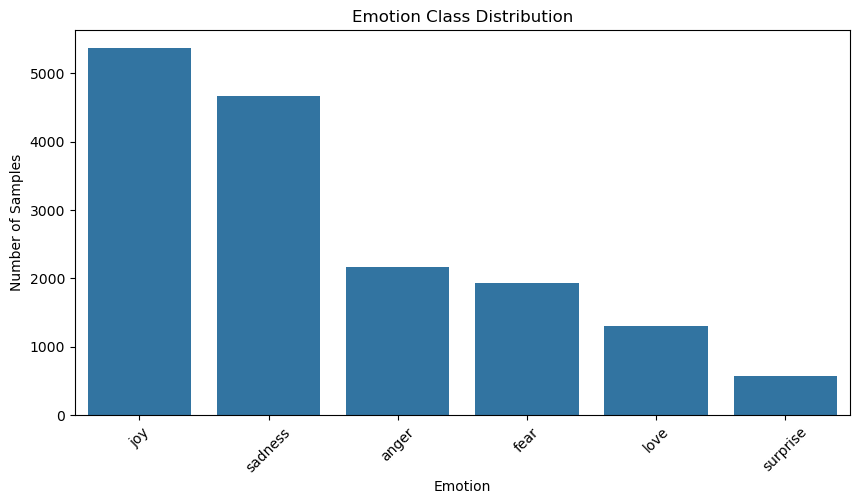

In [12]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="label",
    order=train_df["label"].value_counts().index
)

plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

In [13]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

text     0
label    0
dtype: int64
text     0
label    0
dtype: int64
text     0
label    0
dtype: int64


In [14]:
print("Duplicates before:")
print(train_df.duplicated().sum())

Duplicates before:
1


In [15]:
train_df = train_df.drop_duplicates().reset_index(drop=True)
val_df = val_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

In [16]:
train_df["word_count"] = train_df["text"].apply(
    lambda x: len(str(x).split())
)

train_df["char_count"] = train_df["text"].apply(
    lambda x: len(str(x))
)

train_df[["word_count", "char_count"]].describe()

,word_count,char_count
count,15999.000000,15999.000000
mean,19.166760,96.847990
std,10.987102,55.906021
min,2.000000,7.000000
25%,11.000000,53.000000
50%,17.000000,86.000000
75%,25.000000,129.000000
max,66.000000,300.000000


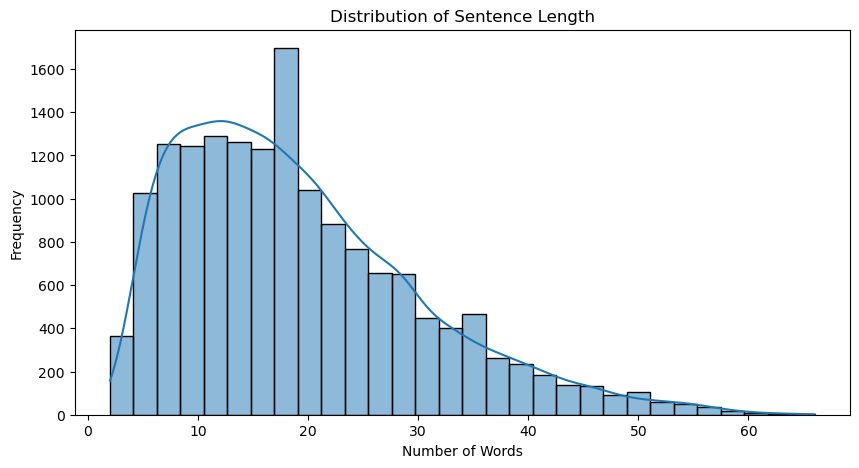

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train_df["word_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Sentence Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [18]:
NEGATION_WORDS = {
    "no",
    "not",
    "nor",
    "never",
    "neither",
    "hardly",
    "scarcely",
    "barely",
    "without"
}

In [19]:
stop_words = set(stopwords.words("english"))

stop_words = stop_words - NEGATION_WORDS

print("Number of stopwords:", len(stop_words))

Number of stopwords: 195


In [20]:
lemmatizer = WordNetLemmatizer()

In [21]:
def clean_text(text):
    
    # Convert to string
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Keep only alphabetic characters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Split sentence into words
    words = text.split()
    
    # Remove stopwords but keep negations
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]
    
    # Join words back
    cleaned_text = " ".join(words)
    
    return cleaned_text

In [22]:
train_df["clean_text"] = train_df["text"].apply(clean_text)

val_df["clean_text"] = val_df["text"].apply(clean_text)

test_df["clean_text"] = test_df["text"].apply(clean_text)

In [23]:
for i in range(10):
    print("ORIGINAL :", train_df.loc[i, "text"])
    print("CLEANED  :", train_df.loc[i, "clean_text"])
    print("-" * 80)

ORIGINAL : i didnt feel humiliated
CLEANED  : didnt feel humiliated
--------------------------------------------------------------------------------
ORIGINAL : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
CLEANED  : go feeling hopeless damned hopeful around someone care awake
--------------------------------------------------------------------------------
ORIGINAL : im grabbing a minute to post i feel greedy wrong
CLEANED  : im grabbing minute post feel greedy wrong
--------------------------------------------------------------------------------
ORIGINAL : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
CLEANED  : ever feeling nostalgic fireplace know still property
--------------------------------------------------------------------------------
ORIGINAL : i am feeling grouchy
CLEANED  : feeling grouchy
----------------------------------------------------------------------------

In [24]:
stemmer = PorterStemmer()

In [25]:
def stem_text(text):
    
    text = str(text).lower()
    
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )
    
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )
    
    words = text.split()
    
    words = [
        word
        for word in words
        if word not in stop_words
    ]
    
    words = [
        stemmer.stem(word)
        for word in words
    ]
    
    return " ".join(words)

In [26]:
train_df["stemmed_text"] = train_df["text"].apply(stem_text)

In [27]:
for i in range(5):
    print("Original :", train_df.loc[i, "text"])
    print("Stemmed  :", train_df.loc[i, "stemmed_text"])
    print("Lemmatized:", train_df.loc[i, "clean_text"])
    print("=" * 100)

Original : i didnt feel humiliated
Stemmed  : didnt feel humili
Lemmatized: didnt feel humiliated
Original : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Stemmed  : go feel hopeless damn hope around someon care awak
Lemmatized: go feeling hopeless damned hopeful around someone care awake
Original : im grabbing a minute to post i feel greedy wrong
Stemmed  : im grab minut post feel greedi wrong
Lemmatized: im grabbing minute post feel greedy wrong
Original : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Stemmed  : ever feel nostalg fireplac know still properti
Lemmatized: ever feeling nostalgic fireplace know still property
Original : i am feeling grouchy
Stemmed  : feel grouchi
Lemmatized: feeling grouchy


In [28]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["label"])

y_val = label_encoder.transform(val_df["label"])

y_test = label_encoder.transform(test_df["label"])

In [29]:
print(label_encoder.classes_)

['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


In [30]:
num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)

Number of classes: 6


In [31]:
X_train_text = train_df["clean_text"].values

X_val_text = val_df["clean_text"].values

X_test_text = test_df["clean_text"].values

In [32]:
MAX_WORDS = 20000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

In [33]:
tokenizer.fit_on_texts(X_train_text)

In [34]:
vocab_size = min(
    MAX_WORDS,
    len(tokenizer.word_index) + 1
)

print("Vocabulary size:", vocab_size)

Vocabulary size: 13487


In [35]:
X_train_seq = tokenizer.texts_to_sequences(X_train_text)

X_val_seq = tokenizer.texts_to_sequences(X_val_text)

X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [36]:
sequence_lengths = [
    len(seq)
    for seq in X_train_seq
]

print("Maximum length:", max(sequence_lengths))

print(
    "95th percentile:",
    int(np.percentile(sequence_lengths, 95))
)

Maximum length: 35
95th percentile: 20


In [39]:
MAX_LEN = 50

In [40]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [41]:
print("X_train:", X_train_pad.shape)
print("X_val:", X_val_pad.shape)
print("X_test:", X_test_pad.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (15999, 50)
X_val: (2000, 50)
X_test: (2000, 50)
y_train: (15999,)
y_val: (2000,)
y_test: (2000,)


In [42]:
EMBEDDING_DIM = 128

In [43]:
def build_simple_rnn():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        SimpleRNN(
            128
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [44]:
def build_lstm():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        LSTM(
            128
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [45]:
def build_gru():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        GRU(
            128
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [46]:
def build_bidirectional_rnn():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        Bidirectional(
            SimpleRNN(128)
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [47]:
def build_bidirectional_lstm():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        Bidirectional(
            LSTM(128)
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [48]:
def build_bidirectional_gru():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        Bidirectional(
            GRU(128)
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [49]:
def build_stacked_rnn():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        SimpleRNN(
            128,
            return_sequences=True
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        SimpleRNN(
            64
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [50]:
def build_stacked_lstm():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        LSTM(
            128,
            return_sequences=True
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        LSTM(
            64
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [51]:
def build_stacked_gru():
    
    model = Sequential()
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        GRU(
            128,
            return_sequences=True
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        GRU(
            64
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(0.3)
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [52]:
model_builders = {
    "Simple RNN": build_simple_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "Bidirectional RNN": build_bidirectional_rnn,
    "Bidirectional LSTM": build_bidirectional_lstm,
    "Bidirectional GRU": build_bidirectional_gru,
    "Stacked RNN": build_stacked_rnn,
    "Stacked LSTM": build_stacked_lstm,
    "Stacked GRU": build_stacked_gru
}

In [53]:
def get_callbacks():
    
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6
    )
    
    return [
        early_stopping,
        reduce_lr
    ]

In [54]:
histories = {}

trained_models = {}

results = []

In [55]:
def train_model(model_name, model_builder):
    
    print("=" * 80)
    print("Training:", model_name)
    print("=" * 80)
    
    model = model_builder()
    
    history = model.fit(
        X_train_pad,
        y_train,
        validation_data=(
            X_val_pad,
            y_val
        ),
        epochs=15,
        batch_size=64,
        callbacks=get_callbacks(),
        verbose=1
    )
    
    trained_models[model_name] = model
    histories[model_name] = history
    
    return model, history

In [56]:
for model_name, model_builder in model_builders.items():
    
    train_model(
        model_name,
        model_builder
    )

Training: Simple RNN
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.3265 - loss: 1.5780 - val_accuracy: 0.3085 - val_loss: 1.5086 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3769 - loss: 1.3952 - val_accuracy: 0.3985 - val_loss: 1.3598 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.3556 - loss: 1.4540 - val_accuracy: 0.3600 - val_loss: 1.4793 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.4066 - loss: 1.2905 - val_accuracy: 0.4115 - val_loss: 1.3273 - learning_rate: 5.0000e-04
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.4323 - loss: 1.1815 - val_accuracy: 0.4015 - val_loss: 1.3156 - learning_rate: 5.0000e-04
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.4344 - loss: 1.1949 - val_accuracy: 0.4230 - val_loss: 1.2727 - learning_rate: 5.0000e-04
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/

In [57]:
trained_models["LSTM"].summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 128)        │     1,726,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,599,700 (21.36 MB)

 Trainable params: 1,866,566 (7.12 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,733,134 (14.24 MB)

In [58]:
def evaluate_model(
    model_name,
    model,
    X,
    y
):
    
    probabilities = model.predict(
        X,
        verbose=0
    )
    
    predictions = np.argmax(
        probabilities,
        axis=1
    )
    
    accuracy = accuracy_score(
        y,
        predictions
    )
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y,
        predictions,
        average="weighted",
        zero_division=0
    )
    
    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y,
            predictions,
            average="macro",
            zero_division=0
        )
    )
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": f1,
        "Macro F1": macro_f1
    }

In [59]:
results = []

for model_name, model in trained_models.items():
    
    result = evaluate_model(
        model_name,
        model,
        X_test_pad,
        y_test
    )
    
    results.append(result)

In [60]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
5,Bidirectional GRU,0.9010,0.903416,0.9010,0.901735,0.857843
4,Bidirectional LSTM,0.8995,0.900088,0.8995,0.899441,0.845573
3,Bidirectional RNN,0.8330,0.830679,0.8330,0.831284,0.753632
0,Simple RNN,0.5345,0.510593,0.5345,0.519521,0.353799
2,GRU,0.3475,0.120756,0.3475,0.179230,0.085962
1,LSTM,0.3475,0.120756,0.3475,0.179230,0.085962
6,Stacked RNN,0.3475,0.120756,0.3475,0.179230,0.085962
7,Stacked LSTM,0.3475,0.120756,0.3475,0.179230,0.085962
8,Stacked GRU,0.3475,0.120756,0.3475,0.179230,0.085962


In [61]:
def plot_training_history(model_name):
    
    history = histories[model_name].history
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    
    plt.plot(
        history["loss"],
        label="Train Loss"
    )
    
    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )
    
    plt.title(
        f"{model_name} - Loss"
    )
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    
    plt.plot(
        history["accuracy"],
        label="Train Accuracy"
    )
    
    plt.plot(
        history["val_accuracy"],
        label="Validation Accuracy"
    )
    
    plt.title(
        f"{model_name} - Accuracy"
    )
    
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.show()

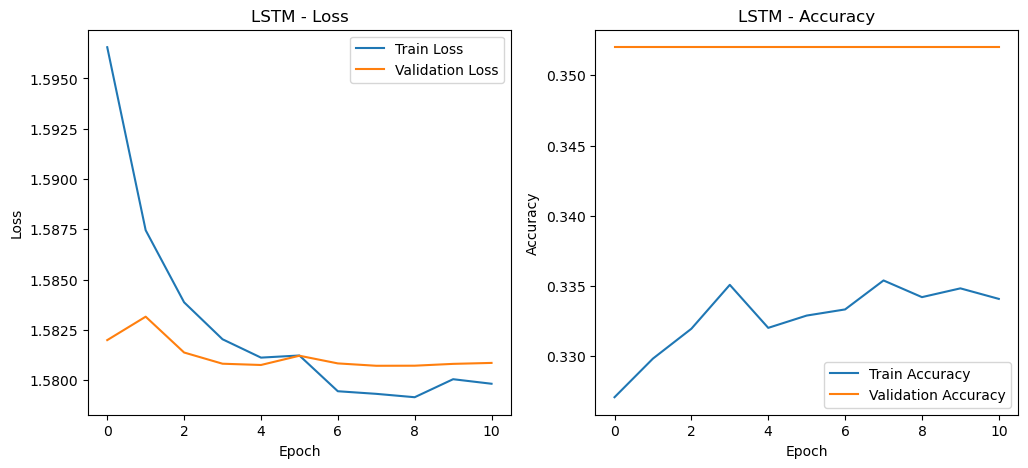

In [62]:
plot_training_history("LSTM")

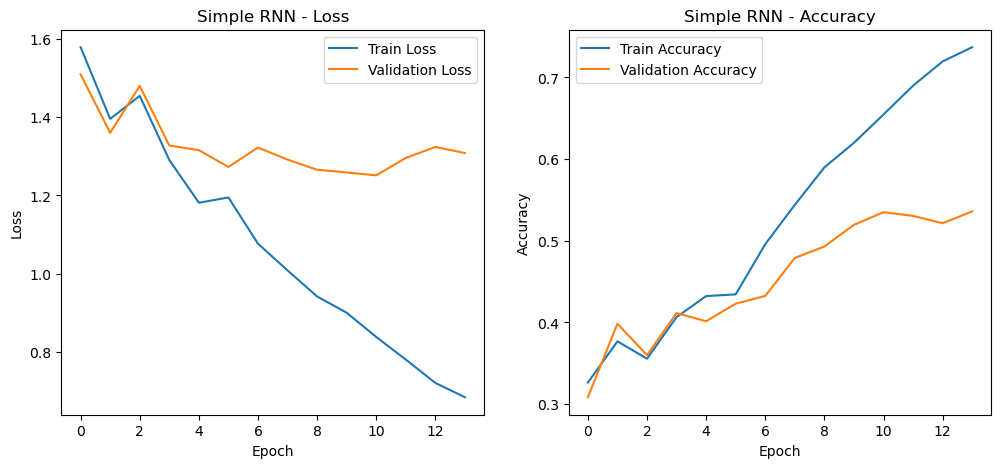

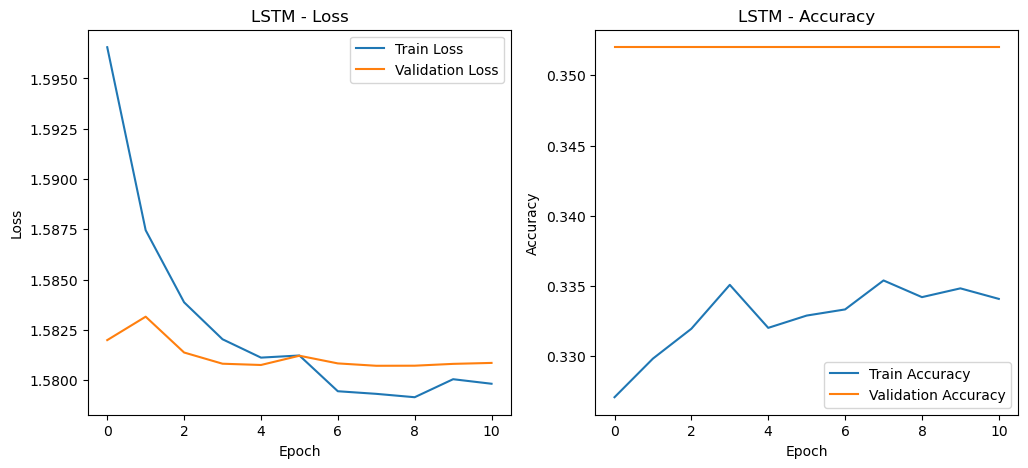

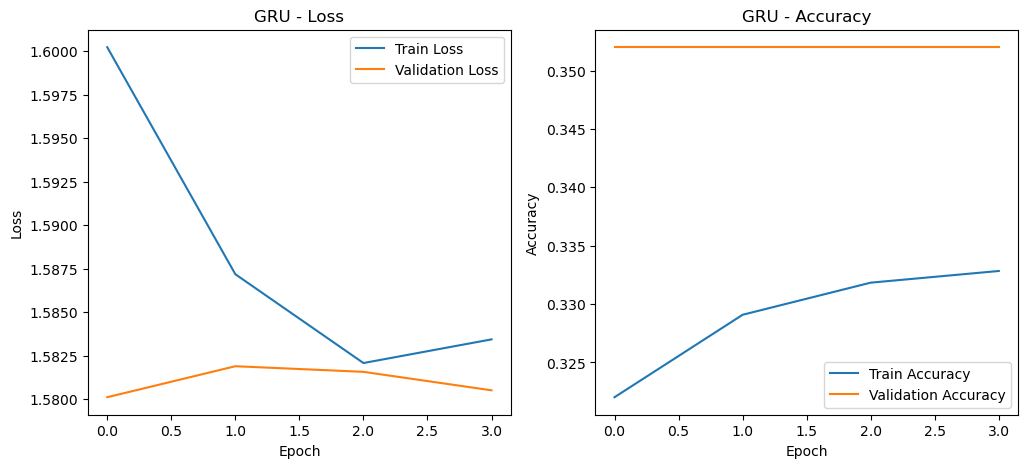

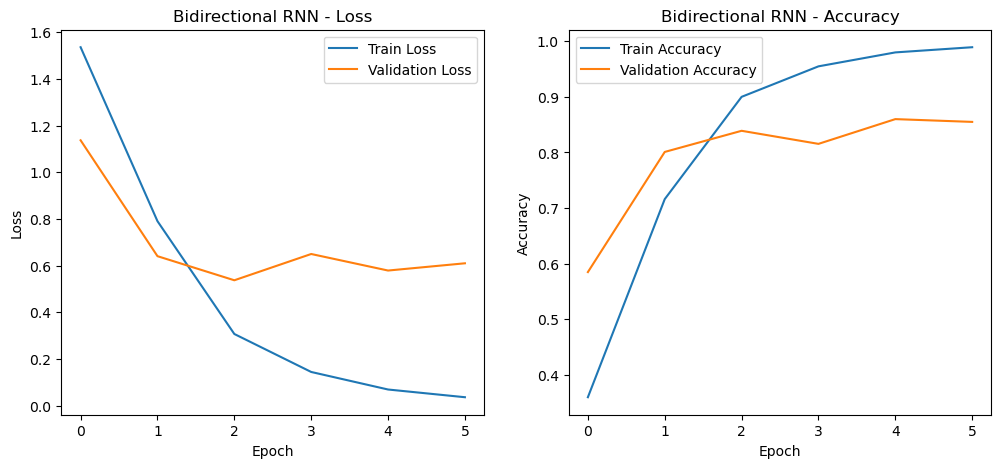

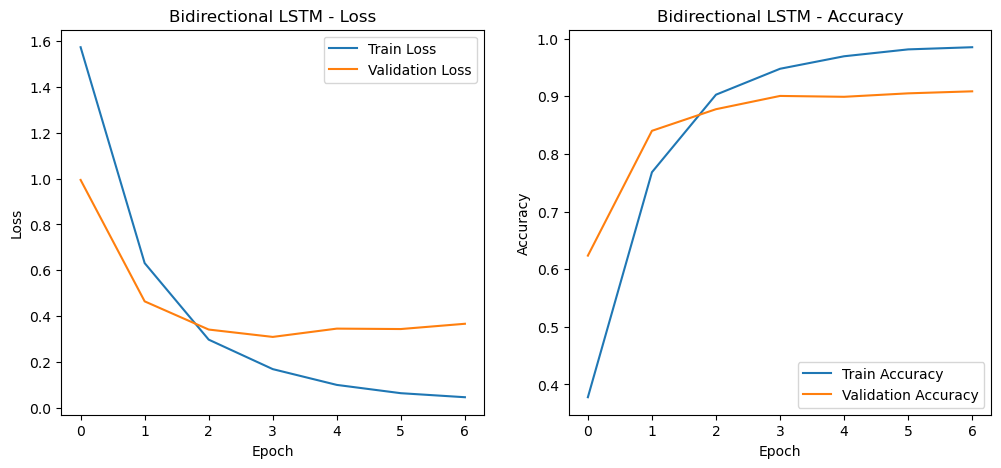

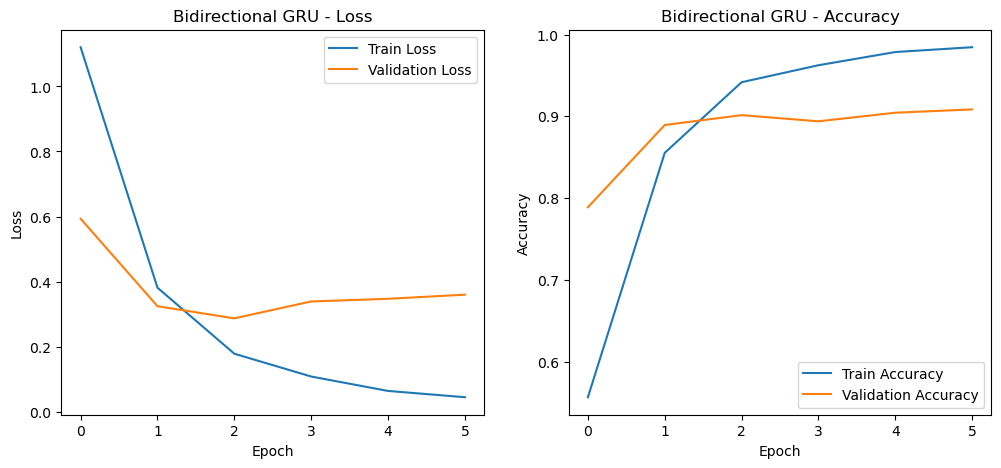

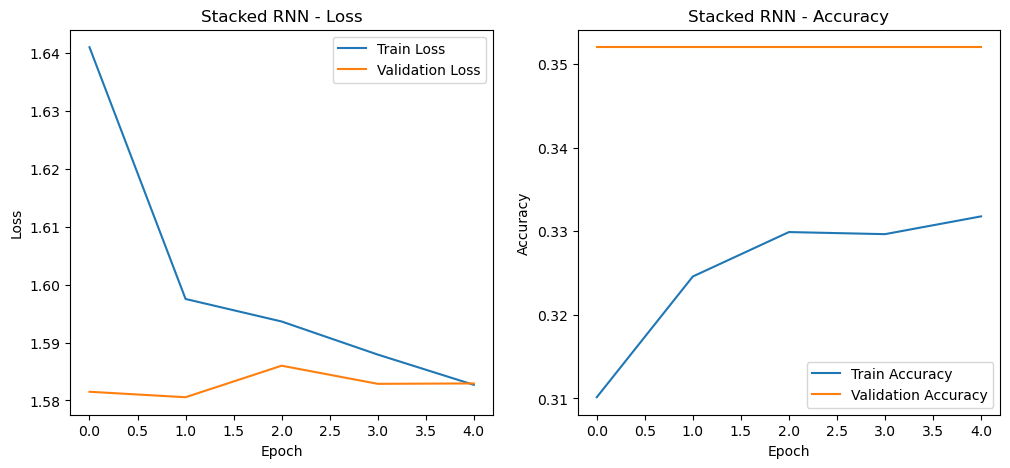

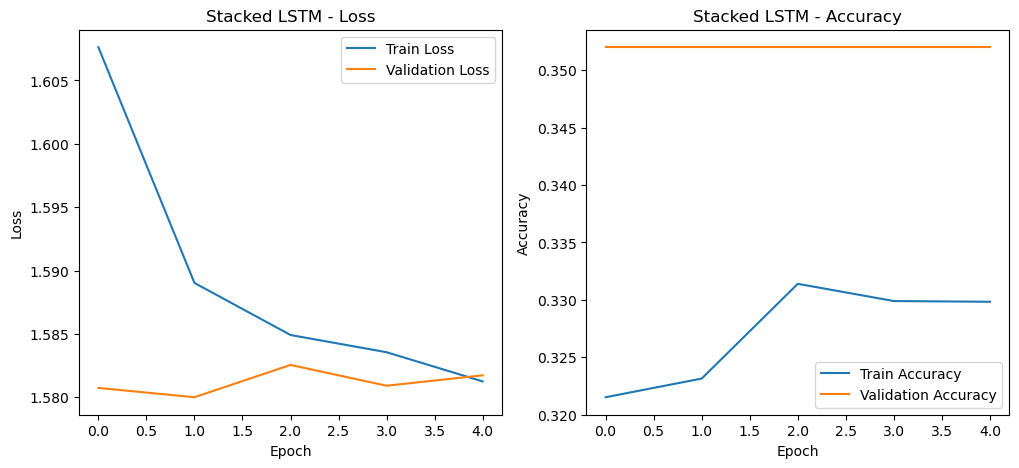

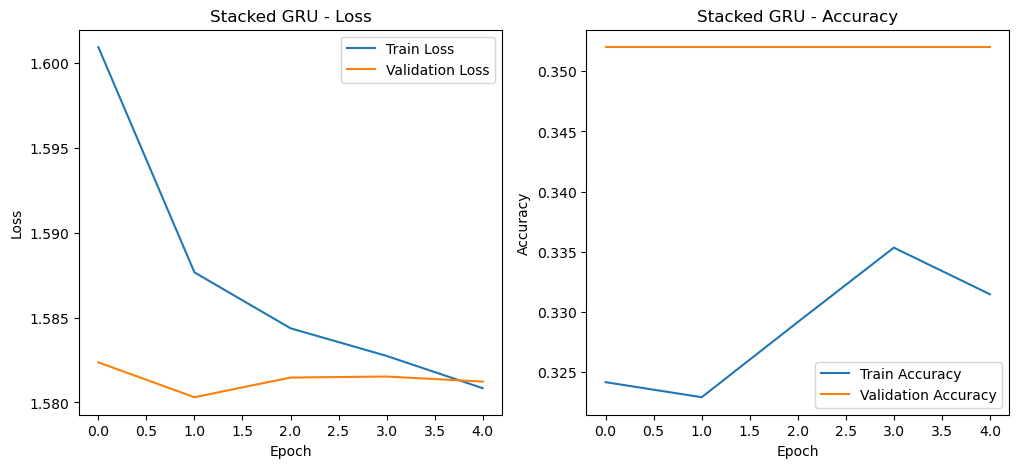

In [63]:
for model_name in histories:
    plot_training_history(model_name)

In [64]:
best_dl_model_name = results_df.iloc[0]["Model"]

In [65]:
best_dl_model = trained_models[
    best_dl_model_name
]

test_probabilities = best_dl_model.predict(
    X_test_pad,
    verbose=0
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

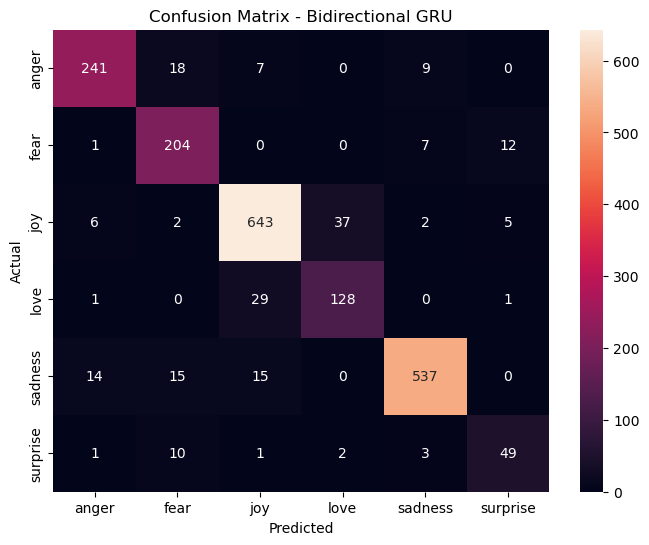

In [66]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Confusion Matrix - {best_dl_model_name}"
)

plt.show()

In [67]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       anger       0.91      0.88      0.89       275
        fear       0.82      0.91      0.86       224
         joy       0.93      0.93      0.93       695
        love       0.77      0.81      0.79       159
     sadness       0.96      0.92      0.94       581
    surprise       0.73      0.74      0.74        66

    accuracy                           0.90      2000
   macro avg       0.85      0.86      0.86      2000
weighted avg       0.90      0.90      0.90      2000



In [73]:
!pip install tensorboard

  Using cached tensorboard-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
Using cached tensorboard-2.21.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)

   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   ---------------------------------------- 2/2 [tensorboard]



In [74]:
def build_tunable_lstm(hp):
    
    model = Sequential()
    
    embedding_dim = hp.Choice(
        "embedding_dim",
        values=[64, 128, 256]
    )
    
    lstm_units = hp.Int(
        "lstm_units",
        min_value=64,
        max_value=256,
        step=64
    )
    
    dense_units = hp.Int(
        "dense_units",
        min_value=32,
        max_value=128,
        step=32
    )
    
    dropout_rate = hp.Float(
        "dropout",
        min_value=0.2,
        max_value=0.5,
        step=0.1
    )
    
    learning_rate = hp.Choice(
        "learning_rate",
        values=[
            0.001,
            0.0005,
            0.0001
        ]
    )
    
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=MAX_LEN
        )
    )
    
    model.add(
        LSTM(
            lstm_units
        )
    )
    
    model.add(
        Dropout(
            dropout_rate
        )
    )
    
    model.add(
        Dense(
            dense_units,
            activation="relu"
        )
    )
    
    model.add(
        Dropout(
            dropout_rate
        )
    )
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )
    
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [75]:
tuner = kt.RandomSearch(
    build_tunable_lstm,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="keras_tuner_results",
    project_name="emotion_lstm"
)

Reloading Tuner from keras_tuner_results\emotion_lstm\tuner0.json


In [76]:
tuner.search(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=8,
    batch_size=64,
    callbacks=get_callbacks()
)

Trial 10 Complete [00h 04m 19s]
val_accuracy: 0.35199999809265137

Best val_accuracy So Far: 0.49399998784065247
Total elapsed time: 00h 34m 30s


In [77]:
best_hps = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

In [78]:
print(
    "Best embedding dimension:",
    best_hps.get("embedding_dim")
)

print(
    "Best LSTM units:",
    best_hps.get("lstm_units")
)

print(
    "Best dense units:",
    best_hps.get("dense_units")
)

print(
    "Best dropout:",
    best_hps.get("dropout")
)

print(
    "Best learning rate:",
    best_hps.get("learning_rate")
)

Best embedding dimension: 64
Best LSTM units: 128
Best dense units: 128
Best dropout: 0.30000000000000004
Best learning rate: 0.0001


In [79]:
best_tuned_lstm = tuner.hypermodel.build(
    best_hps
)

In [80]:
best_tuned_history = best_tuned_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=15,
    batch_size=64,
    callbacks=get_callbacks()
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.3193 - loss: 1.6283 - val_accuracy: 0.3520 - val_loss: 1.5806 - learning_rate: 1.0000e-04
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.3250 - loss: 1.5906 - val_accuracy: 0.3520 - val_loss: 1.5799 - learning_rate: 1.0000e-04
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.3205 - loss: 1.5897 - val_accuracy: 0.3520 - val_loss: 1.5800 - learning_rate: 1.0000e-04
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.3233 - loss: 1.5881 - val_accuracy: 0.3520 - val_loss: 1.5795 - learning_rate: 5.0000e-05
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.3247 - loss: 1.5841 - val_accuracy: 0.3520 - val_loss: 1.5786 - learning_rate: 5.0000e-05
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.3267 - loss: 1.5775 - val_accuracy: 0.3520 - val_loss: 1.5263 - learning_rate: 5.0000e-05
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/ste

In [81]:
tuned_result = evaluate_model(
    "Tuned LSTM",
    best_tuned_lstm,
    X_test_pad,
    y_test
)

tuned_result

{'Model': 'Tuned LSTM',
 'Accuracy': 0.573,
 'Precision': 0.6183300270082873,
 'Recall': 0.573,
 'Weighted F1': 0.5252897778807342,
 'Macro F1': 0.3307673803629808}

In [82]:
transformer_train = train_df[
    ["text", "label"]
].copy()

transformer_val = val_df[
    ["text", "label"]
].copy()

transformer_test = test_df[
    ["text", "label"]
].copy()

In [83]:
transformer_train["label_id"] = label_encoder.transform(
    transformer_train["label"]
)

transformer_val["label_id"] = label_encoder.transform(
    transformer_val["label"]
)

transformer_test["label_id"] = label_encoder.transform(
    transformer_test["label"]
)

In [84]:
from datasets import Dataset

In [85]:
train_hf = Dataset.from_pandas(
    transformer_train[
        ["text", "label_id"]
    ]
)

val_hf = Dataset.from_pandas(
    transformer_val[
        ["text", "label_id"]
    ]
)

test_hf = Dataset.from_pandas(
    transformer_test[
        ["text", "label_id"]
    ]
)

In [86]:
from transformers import AutoTokenizer

In [87]:
bert_model_name = "bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(
    bert_model_name
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [88]:
def tokenize_bert(batch):
    
    return bert_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

In [89]:
train_bert = train_hf.map(
    tokenize_bert,
    batched=True
)

val_bert = val_hf.map(
    tokenize_bert,
    batched=True
)

test_bert = test_hf.map(
    tokenize_bert,
    batched=True
)

Map:   0%|          | 0/15999 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [90]:
from transformers import (
    AutoModelForSequenceClassification
)

In [91]:
id2label = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

label2id = {
    label: i
    for i, label in enumerate(label_encoder.classes_)
}

In [92]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [93]:
from transformers import TrainingArguments

In [95]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_emotion",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    report_to="none"
)

In [96]:
evaluation_strategy="epoch"

In [97]:
def compute_metrics(eval_pred):
    
    logits, labels = eval_pred
    
    predictions = np.argmax(
        logits,
        axis=-1
    )
    
    accuracy = accuracy_score(
        labels,
        predictions
    )
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )
    
    _, _, macro_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1
    }

In [98]:
train_bert = train_bert.rename_column(
    "label_id",
    "labels"
)

val_bert = val_bert.rename_column(
    "label_id",
    "labels"
)

test_bert = test_bert.rename_column(
    "label_id",
    "labels"
)

In [99]:
columns_to_remove = [
    col
    for col in train_bert.column_names
    if col not in [
        "input_ids",
        "token_type_ids",
        "attention_mask",
        "labels"
    ]
]

train_bert = train_bert.remove_columns(
    columns_to_remove
)

val_bert = val_bert.remove_columns(
    [
        col
        for col in val_bert.column_names
        if col not in [
            "input_ids",
            "token_type_ids",
            "attention_mask",
            "labels"
        ]
    ]
)

test_bert = test_bert.remove_columns(
    [
        col
        for col in test_bert.column_names
        if col not in [
            "input_ids",
            "token_type_ids",
            "attention_mask",
            "labels"
        ]
    ]
)

In [100]:
from transformers import Trainer

In [102]:
from transformers import Trainer

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_bert,
    eval_dataset=val_bert,
    processing_class=bert_tokenizer,
    compute_metrics=compute_metrics
)

In [104]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,0.140042,0.157946,0.943500,0.944149,0.943500,0.943492,0.920704
2,0.103223,0.182705,0.940500,0.941590,0.940500,0.940078,0.915361
3,0.068034,0.202916,0.937500,0.937803,0.937500,0.937568,0.911815


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=3000, training_loss=0.11297317504882813, metrics={'train_runtime': 14326.6474, 'train_samples_per_second': 3.35, 'train_steps_per_second': 0.209, 'total_flos': 1578624358802688.0, 'train_loss': 0.11297317504882813, 'epoch': 3.0})

In [105]:
bert_metrics = trainer.evaluate(
    test_bert
)

bert_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Macro F1
0.068034,0.200690,3,0.927000,0.929869,0.927000,0.927740,0.885582


{'eval_loss': 0.20069004595279694,
 'eval_accuracy': 0.927,
 'eval_precision': 0.9298686509499978,
 'eval_recall': 0.927,
 'eval_f1': 0.9277399536647871,
 'eval_macro_f1': 0.8855816944887661}

In [106]:
bert_predictions = trainer.predict(
    test_bert
)

In [107]:
bert_pred_labels = np.argmax(
    bert_predictions.predictions,
    axis=1
)

In [108]:
print(
    classification_report(
        y_test,
        bert_pred_labels,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       anger       0.91      0.94      0.93       275
        fear       0.92      0.85      0.88       224
         joy       0.96      0.93      0.95       695
        love       0.79      0.91      0.84       159
     sadness       0.96      0.97      0.96       581
    surprise       0.71      0.79      0.75        66

    accuracy                           0.93      2000
   macro avg       0.88      0.90      0.89      2000
weighted avg       0.93      0.93      0.93      2000



In [109]:
distilbert_model_name = "distilbert-base-uncased"

distilbert_tokenizer = AutoTokenizer.from_pretrained(
    distilbert_model_name
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [110]:
def tokenize_distilbert(batch):
    
    return distilbert_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

In [111]:
train_distilbert = train_hf.map(
    tokenize_distilbert,
    batched=True
)

val_distilbert = val_hf.map(
    tokenize_distilbert,
    batched=True
)

test_distilbert = test_hf.map(
    tokenize_distilbert,
    batched=True
)

Map:   0%|          | 0/15999 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [112]:
train_distilbert = train_distilbert.rename_column(
    "label_id",
    "labels"
)

val_distilbert = val_distilbert.rename_column(
    "label_id",
    "labels"
)

test_distilbert = test_distilbert.rename_column(
    "label_id",
    "labels"
)

In [113]:
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    distilbert_model_name,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [114]:
allowed_columns = {
    "input_ids",
    "attention_mask",
    "labels"
}

train_distilbert = train_distilbert.remove_columns(
    [
        c for c in train_distilbert.column_names
        if c not in allowed_columns
    ]
)

val_distilbert = val_distilbert.remove_columns(
    [
        c for c in val_distilbert.column_names
        if c not in allowed_columns
    ]
)

test_distilbert = test_distilbert.remove_columns(
    [
        c for c in test_distilbert.column_names
        if c not in allowed_columns
    ]
)

In [116]:
from transformers import Trainer, TrainingArguments

distilbert_training_args = TrainingArguments(
    output_dir="./distilbert_emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=train_distilbert,
    eval_dataset=val_distilbert,
    processing_class=distilbert_tokenizer,
    compute_metrics=compute_metrics
)

In [117]:
distilbert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,0.244875,0.191499,0.930000,0.930812,0.930000,0.929712,0.904549
2,0.143338,0.165280,0.938000,0.939587,0.938000,0.937966,0.910786
3,0.097931,0.149017,0.940000,0.941603,0.940000,0.940505,0.914395


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.24646343231201173, metrics={'train_runtime': 6753.5595, 'train_samples_per_second': 7.107, 'train_steps_per_second': 0.444, 'total_flos': 794811409949952.0, 'train_loss': 0.24646343231201173, 'epoch': 3.0})

In [118]:
distilbert_metrics = distilbert_trainer.evaluate(
    test_distilbert
)

distilbert_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Macro F1
0.097931,0.170992,3,0.926000,0.928466,0.926000,0.926880,0.885392


{'eval_loss': 0.17099206149578094,
 'eval_accuracy': 0.926,
 'eval_precision': 0.9284663211683072,
 'eval_recall': 0.926,
 'eval_f1': 0.9268804222766531,
 'eval_macro_f1': 0.8853924895027135}

In [119]:
roberta_model_name = "roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(
    roberta_model_name
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [120]:
def tokenize_roberta(batch):
    
    return roberta_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

In [121]:
train_roberta = train_hf.map(
    tokenize_roberta,
    batched=True
)

val_roberta = val_hf.map(
    tokenize_roberta,
    batched=True
)

test_roberta = test_hf.map(
    tokenize_roberta,
    batched=True
)

Map:   0%|          | 0/15999 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [122]:
train_roberta = train_roberta.rename_column(
    "label_id",
    "labels"
)

val_roberta = val_roberta.rename_column(
    "label_id",
    "labels"
)

test_roberta = test_roberta.rename_column(
    "label_id",
    "labels"
)

In [123]:
allowed_columns = {
    "input_ids",
    "attention_mask",
    "labels"
}

train_roberta = train_roberta.remove_columns(
    [
        c for c in train_roberta.column_names
        if c not in allowed_columns
    ]
)

val_roberta = val_roberta.remove_columns(
    [
        c for c in val_roberta.column_names
        if c not in allowed_columns
    ]
)

test_roberta = test_roberta.remove_columns(
    [
        c for c in test_roberta.column_names
        if c not in allowed_columns
    ]
)

In [124]:
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [125]:
roberta_training_args = TrainingArguments(
    output_dir="./roberta_emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

In [127]:
from transformers import Trainer

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=train_roberta,
    eval_dataset=val_roberta,
    processing_class=roberta_tokenizer,
    compute_metrics=compute_metrics
)

In [129]:
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,0.299747,0.237253,0.924500,0.925897,0.924500,0.923849,0.896795
2,0.186879,0.173721,0.936500,0.938493,0.936500,0.936668,0.910561
3,0.120065,0.148529,0.936000,0.937023,0.936000,0.936349,0.910299


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.29000659434000653, metrics={'train_runtime': 15663.4327, 'train_samples_per_second': 3.064, 'train_steps_per_second': 0.192, 'total_flos': 1578624358802688.0, 'train_loss': 0.29000659434000653, 'epoch': 3.0})

In [130]:
roberta_metrics = roberta_trainer.evaluate(
    test_roberta
)

roberta_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Macro F1
0.120065,0.201582,3,0.924500,0.926567,0.924500,0.923919,0.880581


{'eval_loss': 0.20158205926418304,
 'eval_accuracy': 0.9245,
 'eval_precision': 0.9265674197070678,
 'eval_recall': 0.9245,
 'eval_f1': 0.9239194102023865,
 'eval_macro_f1': 0.8805814802777988}

In [131]:
transformer_results = pd.DataFrame([
    {
        "Model": "BERT",
        "Accuracy": bert_metrics["eval_accuracy"],
        "Weighted F1": bert_metrics["eval_f1"],
        "Macro F1": bert_metrics["eval_macro_f1"]
    },
    {
        "Model": "DistilBERT",
        "Accuracy": distilbert_metrics["eval_accuracy"],
        "Weighted F1": distilbert_metrics["eval_f1"],
        "Macro F1": distilbert_metrics["eval_macro_f1"]
    },
    {
        "Model": "RoBERTa",
        "Accuracy": roberta_metrics["eval_accuracy"],
        "Weighted F1": roberta_metrics["eval_f1"],
        "Macro F1": roberta_metrics["eval_macro_f1"]
    }
])

transformer_results

,Model,Accuracy,Weighted F1,Macro F1
0,BERT,0.9270,0.927740,0.885582
1,DistilBERT,0.9260,0.926880,0.885392
2,RoBERTa,0.9245,0.923919,0.880581


In [132]:
all_results = pd.concat(
    [
        results_df,
        pd.DataFrame([tuned_result]),
        transformer_results
    ],
    ignore_index=True
)

In [133]:
all_results = all_results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

all_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,BERT,0.9270,NaN,NaN,0.927740,0.885582
1,DistilBERT,0.9260,NaN,NaN,0.926880,0.885392
2,RoBERTa,0.9245,NaN,NaN,0.923919,0.880581
3,Bidirectional GRU,0.9010,0.903416,0.9010,0.901735,0.857843
4,Bidirectional LSTM,0.8995,0.900088,0.8995,0.899441,0.845573
5,Bidirectional RNN,0.8330,0.830679,0.8330,0.831284,0.753632
6,Simple RNN,0.5345,0.510593,0.5345,0.519521,0.353799
7,Tuned LSTM,0.5730,0.618330,0.5730,0.525290,0.330767
8,GRU,0.3475,0.120756,0.3475,0.179230,0.085962
9,Stacked GRU,0.3475,0.120756,0.3475,0.179230,0.085962


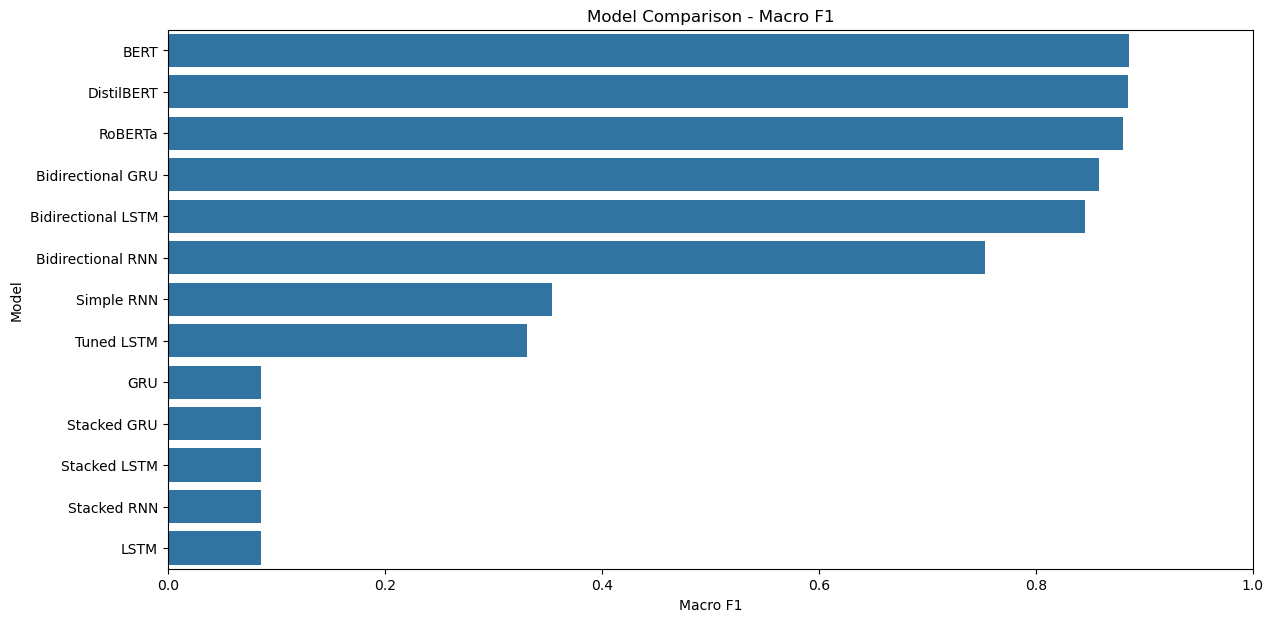

In [134]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=all_results,
    x="Macro F1",
    y="Model"
)

plt.title("Model Comparison - Macro F1")

plt.xlim(
    0,
    1
)

plt.show()

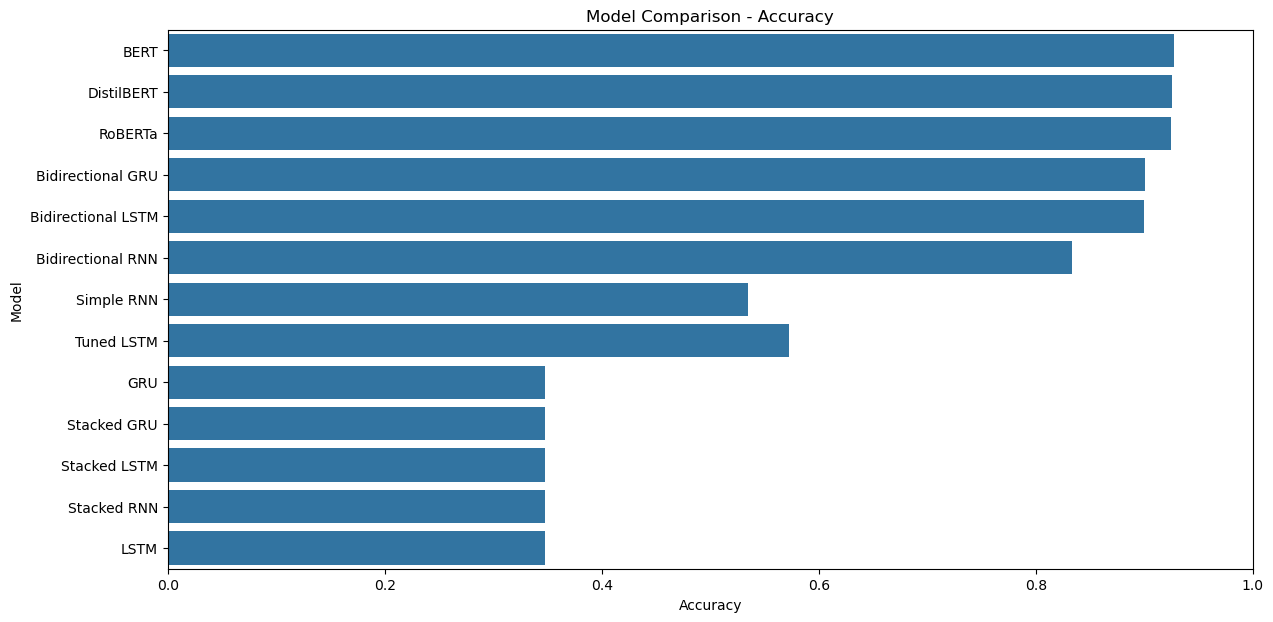

In [135]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=all_results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Comparison - Accuracy")

plt.xlim(
    0,
    1
)

plt.show()

In [136]:
best_model_row = all_results.iloc[0]

print("Best Model:")
print(best_model_row)

Best Model:
Model              BERT
Accuracy          0.927
Precision           NaN
Recall              NaN
Weighted F1     0.92774
Macro F1       0.885582
Name: 0, dtype: object
